In [1]:
# 1일차 핵심 실습
# AI4I 2020 데이터 읽기 -> 확인 -> EDA -> 전처리 -> 저장

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [4]:
# 1. 파일 경로 설정
file_path = "data/raw/ai4i2020.csv"

In [5]:
# 2. 데이터 읽기
df = pd.read_csv(file_path)

print("데이터 크기")
print(df.shape)

데이터 크기
(10000, 14)


In [6]:
print("앞부분 5행")
display(df.head())

앞부분 5행


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [7]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [8]:
df.columns = [
    "udi", "product_id", "type",
    "air_temp_k", "process_temp_k", "rot_speed_rpm",
    "torque_nm", "tool_wear_min",
    "machine_failure", "twf", "hdf", "pwf", "osf", "rnf"
]

print("\n정리된 컬럼명")
print(df.columns.tolist())


정리된 컬럼명
['udi', 'product_id', 'type', 'air_temp_k', 'process_temp_k', 'rot_speed_rpm', 'torque_nm', 'tool_wear_min', 'machine_failure', 'twf', 'hdf', 'pwf', 'osf', 'rnf']


In [9]:
# 4. 기본 정보 확인
print("기본 정보")
df.info()

기본 정보
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   udi              10000 non-null  int64  
 1   product_id       10000 non-null  object 
 2   type             10000 non-null  object 
 3   air_temp_k       10000 non-null  float64
 4   process_temp_k   10000 non-null  float64
 5   rot_speed_rpm    10000 non-null  int64  
 6   torque_nm        10000 non-null  float64
 7   tool_wear_min    10000 non-null  int64  
 8   machine_failure  10000 non-null  int64  
 9   twf              10000 non-null  int64  
 10  hdf              10000 non-null  int64  
 11  pwf              10000 non-null  int64  
 12  osf              10000 non-null  int64  
 13  rnf              10000 non-null  int64  
dtypes: float64(3), int64(9), object(2)
memory usage: 1.1+ MB


In [10]:
print("기초 통계량")
display(df.describe())

기초 통계량


,udi,air_temp_k,process_temp_k,rot_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [11]:
# 5. 결측치 / 중복 확인
print("컬럼별 결측치 개수")
display(df.isnull().sum())

컬럼별 결측치 개수


udi                0
product_id         0
type               0
air_temp_k         0
process_temp_k     0
rot_speed_rpm      0
torque_nm          0
tool_wear_min      0
machine_failure    0
twf                0
hdf                0
pwf                0
osf                0
rnf                0
dtype: int64

In [12]:
print("전체 결측치 개수:", df.isnull().sum().sum())
print("중복 행 개수:", df.duplicated().sum())

전체 결측치 개수: 0
중복 행 개수: 0


In [13]:
# 6. 범주형 분포 확인
print("범주형 분포")
print("type 분포")
display(df["type"].value_counts())

범주형 분포
type 분포


type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [14]:
print("machine_failure 분포")
display(df["machine_failure"].value_counts())

machine_failure 분포


machine_failure
0    9661
1     339
Name: count, dtype: int64

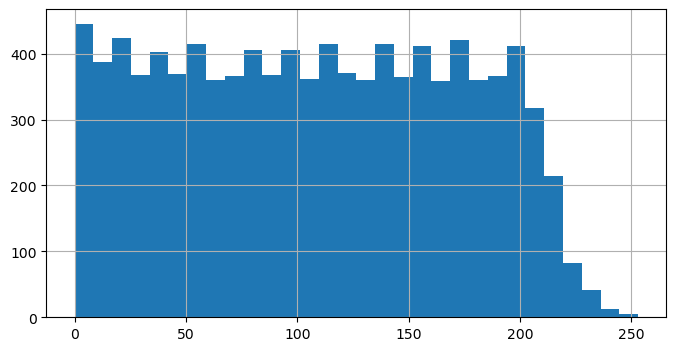

In [15]:
# -------------------------------------------------
# 7. 수치형 분포 시각화
# -------------------------------------------------
plt.figure(figsize=(8, 4))
df["tool_wear_min"].hist(bins=30)
plt.show()

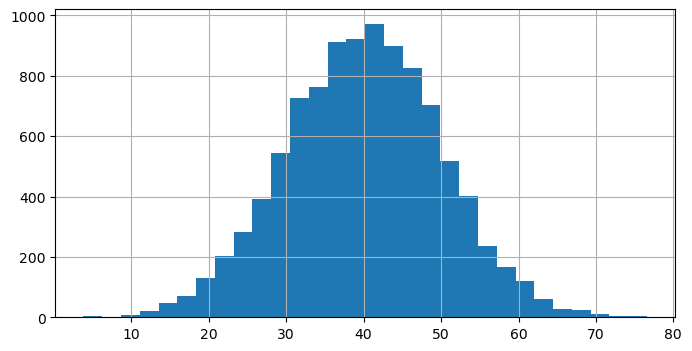

In [16]:
plt.figure(figsize=(8, 4))
df["torque_nm"].hist(bins=30)
plt.show()

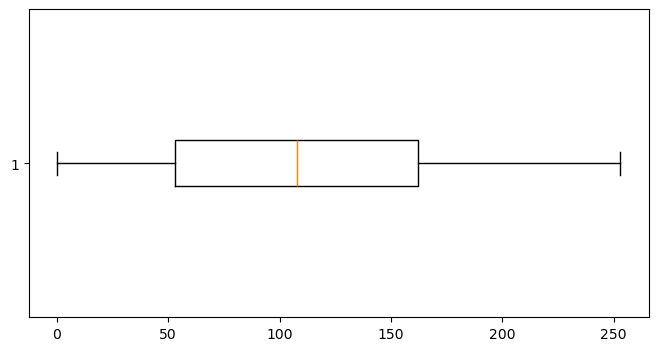

In [17]:
# -------------------------------------------------
# 8. 박스플롯으로 이상치 확인
# -------------------------------------------------
plt.figure(figsize=(8, 4))
plt.boxplot(df["tool_wear_min"], vert=False)
plt.show()

In [18]:
# 9. 그룹별 요약
print("type별 평균")

display(
    df.groupby("type")[["air_temp_k", "process_temp_k", "rot_speed_rpm", "torque_nm", "tool_wear_min"]]
    .mean()
    .round(2)
)

type별 평균


,air_temp_k,process_temp_k,rot_speed_rpm,torque_nm,tool_wear_min
type,,,,,
H,299.87,309.93,1538.15,39.84,107.42
L,300.02,310.01,1539.47,40.00,108.38
M,300.03,310.02,1537.60,40.02,107.27


In [19]:
print("machine_failure별 평균")
display(
    df.groupby("machine_failure")[["air_temp_k", "process_temp_k", "rot_speed_rpm", "torque_nm", "tool_wear_min"]]
    .mean()
    .round(2)
)

machine_failure별 평균


,air_temp_k,process_temp_k,rot_speed_rpm,torque_nm,tool_wear_min
machine_failure,,,,,
0,299.97,310.00,1540.26,39.63,106.69
1,300.89,310.29,1496.49,50.17,143.78


In [20]:
# 10. 파생 변수 만들기
# 공정 온도 - 외기 온도
df["temp_diff_k"] = df["process_temp_k"] - df["air_temp_k"]

# 회전수 * 토크 : 간단한 비교용 지표
df["power_index"] = df["rot_speed_rpm"] * df["torque_nm"]

# 공구 마모 구간화
df["tool_wear_level"] = pd.cut(
    df["tool_wear_min"],
    bins=[-1, 80, 160, 250],
    labels=["low", "mid", "high"]
)

print("파생 변수 확인")
display(
    df[["air_temp_k", "process_temp_k", "temp_diff_k",
        "rot_speed_rpm", "torque_nm", "power_index",
        "tool_wear_min", "tool_wear_level"]].head()
)

파생 변수 확인


,air_temp_k,process_temp_k,temp_diff_k,rot_speed_rpm,torque_nm,power_index,tool_wear_min,tool_wear_level
0,298.1,308.6,10.5,1551,42.8,66382.8,0,low
1,298.2,308.7,10.5,1408,46.3,65190.4,3,low
2,298.1,308.5,10.4,1498,49.4,74001.2,5,low
3,298.2,308.6,10.4,1433,39.5,56603.5,7,low
4,298.2,308.7,10.5,1408,40.0,56320.0,9,low


In [21]:
# 11. 이상치 플래그 만들기
q1 = df["tool_wear_min"].quantile(0.25)
q3 = df["tool_wear_min"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

df["tool_wear_outlier_flag"] = (
    (df["tool_wear_min"] < lower) | (df["tool_wear_min"] > upper)
).astype(int)

print("공구 마모 이상치 개수:", df["tool_wear_outlier_flag"].sum())

공구 마모 이상치 개수: 0


In [22]:
# 12. 조건 필터링 예시
print("\n고장 발생 + 공구 마모 150 이상 데이터")
display(
    df[(df["machine_failure"] == 1) & (df["tool_wear_min"] >= 150)].head()
)


고장 발생 + 공구 마모 150 이상 데이터


,udi,product_id,type,air_temp_k,process_temp_k,rot_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf,temp_diff_k,power_index,tool_wear_level,tool_wear_outlier_flag
69,70,L47249,L,298.9,309.0,1410,65.7,191,1,0,0,1,1,0,10.1,92637.0,high,0
77,78,L47257,L,298.8,308.9,1455,41.3,208,1,1,0,0,0,0,10.1,60091.5,high,0
160,161,L47340,L,298.4,308.2,1282,60.7,216,1,0,0,0,1,0,9.8,77817.4,high,0
161,162,L47341,L,298.3,308.1,1412,52.3,218,1,0,0,0,1,0,9.8,73847.6,high,0
242,243,L47422,L,298.0,308.2,1348,58.8,202,1,0,0,0,1,0,10.2,79262.4,high,0


In [23]:
# 13. 최종 확인
print("최종 데이터 확인")
print("데이터 크기:", df.shape)
print("최종 컬럼 목록")
print(df.columns.tolist())


최종 데이터 확인
데이터 크기: (10000, 18)
최종 컬럼 목록
['udi', 'product_id', 'type', 'air_temp_k', 'process_temp_k', 'rot_speed_rpm', 'torque_nm', 'tool_wear_min', 'machine_failure', 'twf', 'hdf', 'pwf', 'osf', 'rnf', 'temp_diff_k', 'power_index', 'tool_wear_level', 'tool_wear_outlier_flag']


In [24]:
display(df.head())

,udi,product_id,type,air_temp_k,process_temp_k,rot_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf,temp_diff_k,power_index,tool_wear_level,tool_wear_outlier_flag
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,66382.8,low,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,65190.4,low,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,74001.2,low,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,56603.5,low,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,56320.0,low,0


In [25]:
# 14. 저장
output_dir = Path("data/interim")
output_dir.mkdir(parents=True, exist_ok=True)

output_file = output_dir / "ai4i_cleaned.csv"
df.to_csv(output_file, index=False, encoding="utf-8-sig")

print("\n저장 완료:", output_file)


저장 완료: data/interim/ai4i_cleaned.csv


In [26]:
# 15. 저장 후 다시 확인
check_df = pd.read_csv(output_file)

print("저장 후 다시 읽은 데이터 크기:", check_df.shape)
display(check_df.head())

저장 후 다시 읽은 데이터 크기: (10000, 18)


,udi,product_id,type,air_temp_k,process_temp_k,rot_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf,temp_diff_k,power_index,tool_wear_level,tool_wear_outlier_flag
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,66382.8,low,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,65190.4,low,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,74001.2,low,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,56603.5,low,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,56320.0,low,0


In [27]:
# 16. 마무리 요약
print("1일차 실습 요약")
print("1) 원본 데이터를 읽었다.")
print("2) 기본 정보와 결측치/중복을 확인했다.")
print("3) 분포와 그룹별 요약을 확인했다.")
print("4) 파생 변수와 이상치 플래그를 만들었다.")
print("5) 정제 결과를 ai4i_cleaned.csv 로 저장했다.")

1일차 실습 요약
1) 원본 데이터를 읽었다.
2) 기본 정보와 결측치/중복을 확인했다.
3) 분포와 그룹별 요약을 확인했다.
4) 파생 변수와 이상치 플래그를 만들었다.
5) 정제 결과를 ai4i_cleaned.csv 로 저장했다.


In [28]:
# end